## Assignment No.12

# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel("glass.xlsx", sheet_name="glass")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nClass Distribution:\n", df['Type'].value_counts())

Shape: (214, 10)

Data Types:
 RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

First 5 rows:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Summary Statistics:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000  

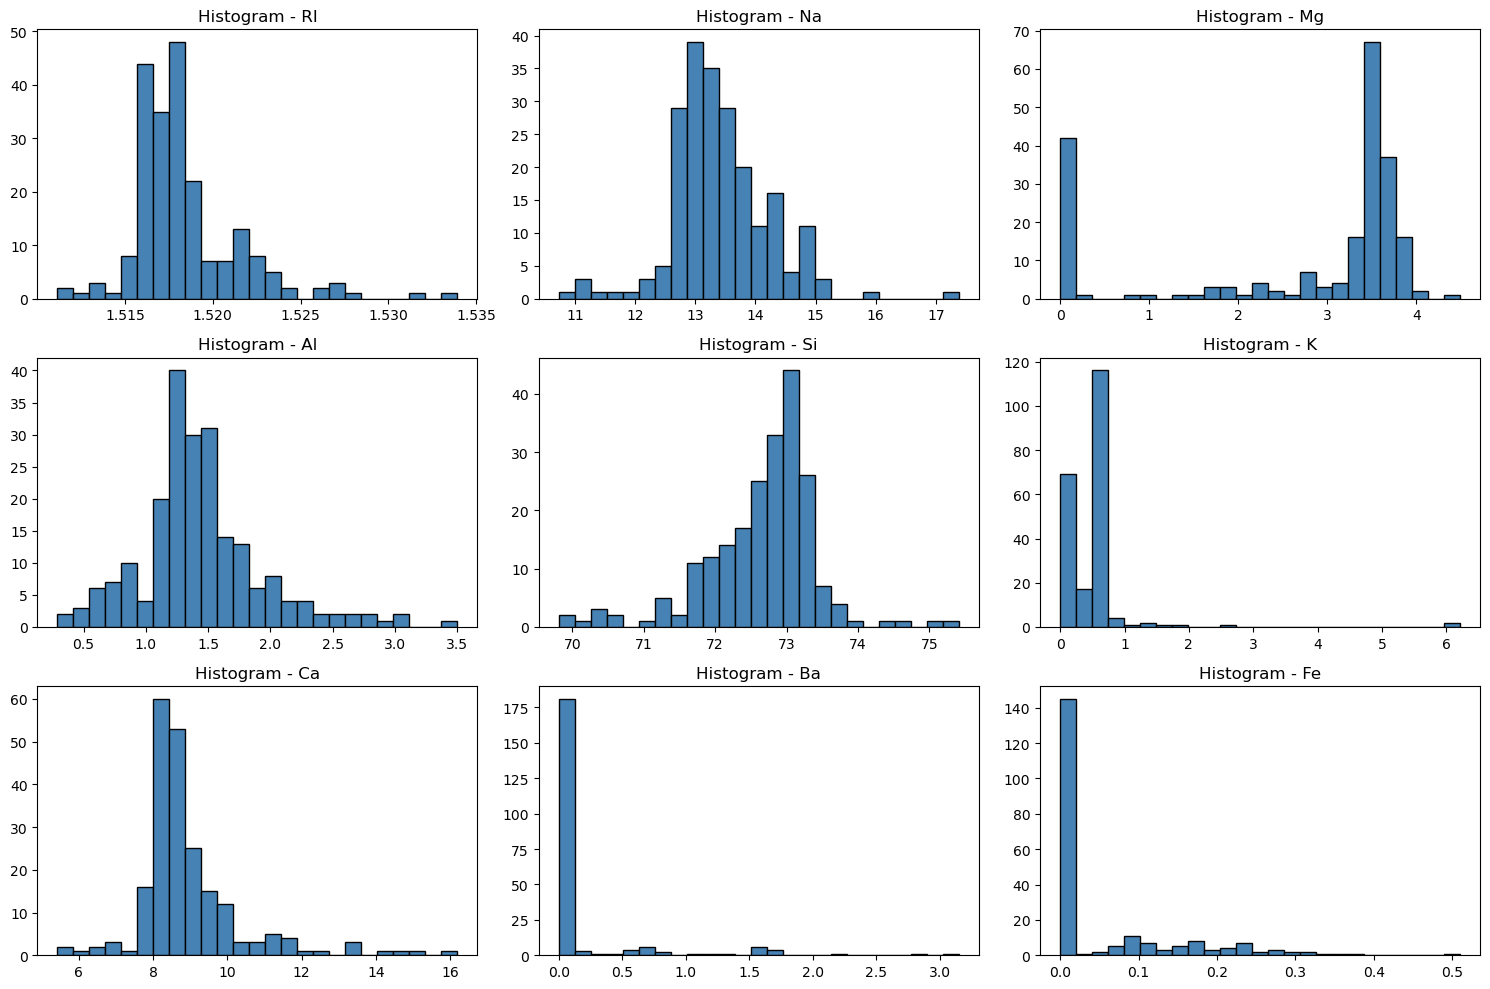

In [2]:
#Histograms
features = df.columns[:-1].tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

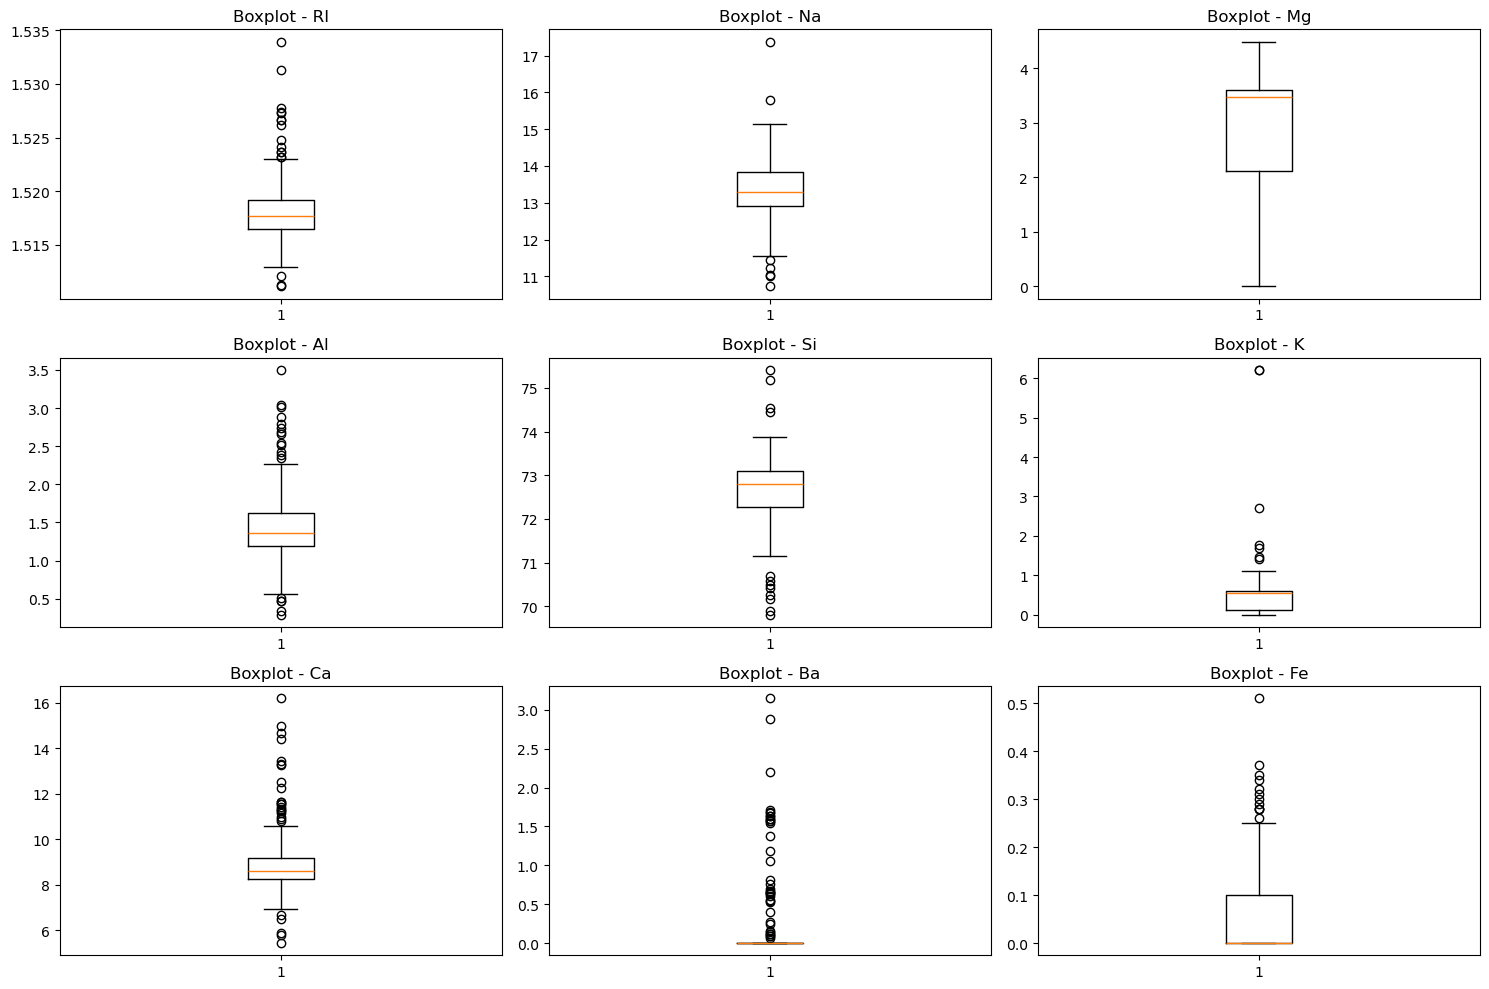

In [3]:
#Box Plots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot - {col}')
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

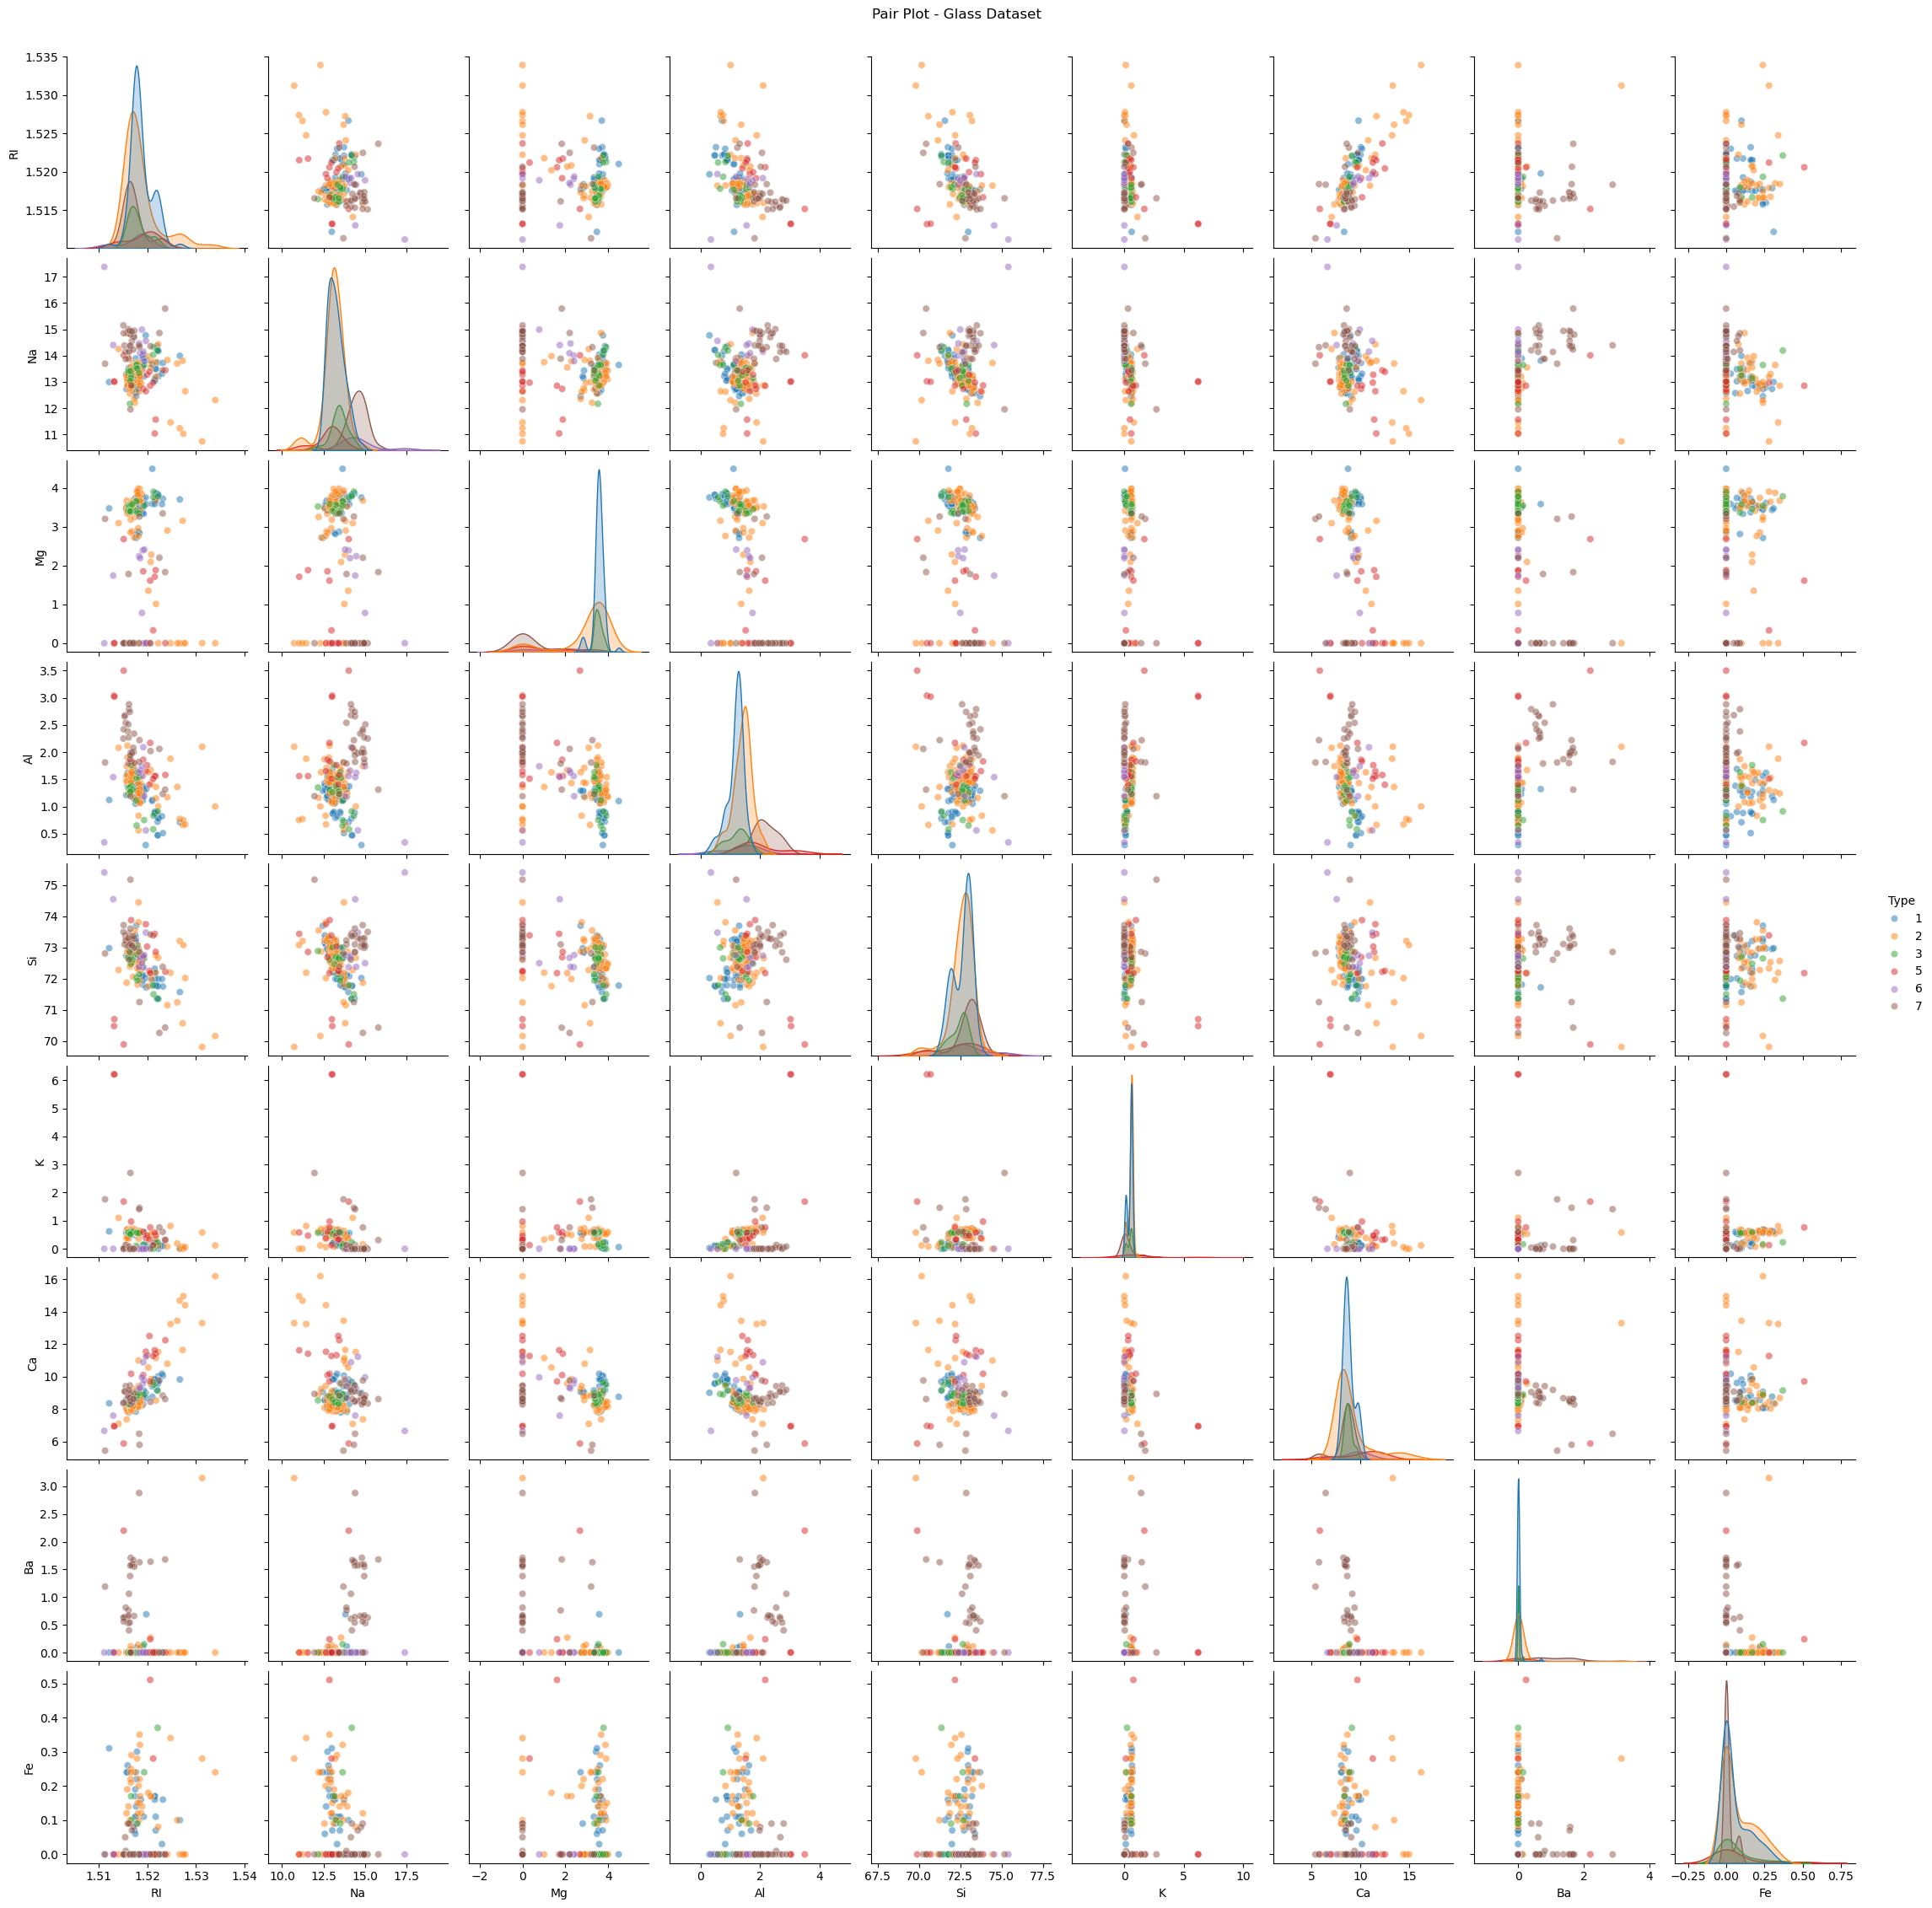

In [4]:
#Pair Plot
sns.pairplot(df, hue='Type', palette='tab10', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot - Glass Dataset', y=1.01)
plt.savefig('pairplot.png')
plt.show()

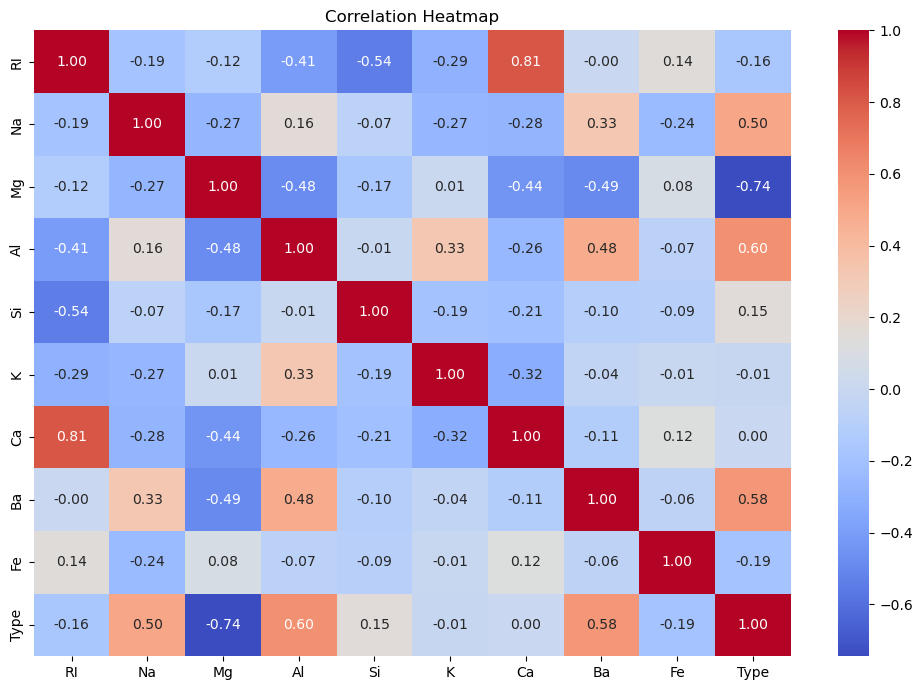

In [5]:
#Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

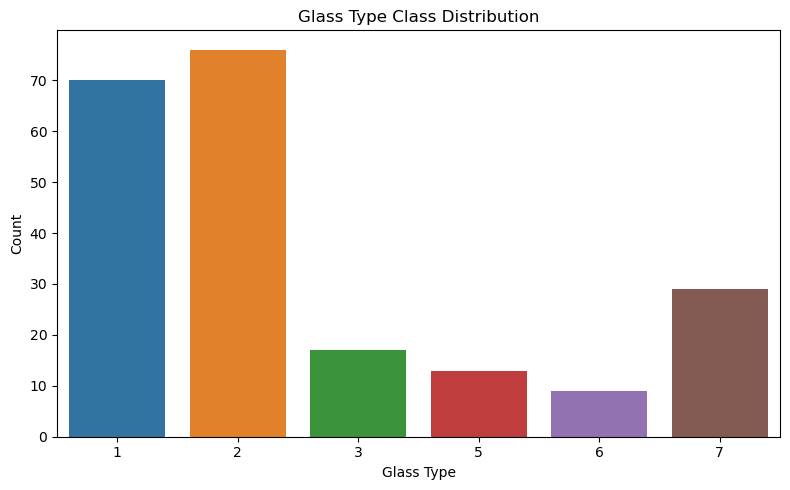

In [6]:
#Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Type', hue='Type', data=df, palette='tab10', legend=False)
plt.title('Glass Type Class Distribution')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# Data Preprocessing

In [7]:
#Missing Values & Duplicates
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)
print("Missing values:\n", df_clean.isnull().sum())

Shape after removing duplicates: (213, 10)
Missing values:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [8]:
#Outlier Treatment using IQR
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

print("Shape after outlier treatment:", df_clean.shape)

Shape after outlier treatment: (213, 10)


In [9]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

X = df_clean.drop('Type', axis=1)
y = df_clean['Type']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(X_scaled.head())

         RI        Na        Mg        Al        Si         K        Ca   Ba  \
0  1.216093  0.322680  1.257238 -0.773927 -1.361078 -1.253536 -0.044419  0.0   
1 -0.227207  0.660556  0.639311 -0.154741  0.086641  0.124799 -1.115733  0.0   
2 -0.834242  0.174014  0.604596  0.273927  0.482859 -0.170559 -1.173956  0.0   
3 -0.205982 -0.258467  0.701798 -0.321445 -0.096228  0.420156 -0.661589  0.0   
4 -0.307862 -0.177377  0.653197 -0.440519  0.620012  0.354521 -0.836260  0.0   

         Fe  
0 -0.621102  
1 -0.621102  
2 -0.621102  
3 -0.621102  
4 -0.621102  


In [10]:
#Handling Imbalanced Data using SMOTE
from imblearn.over_sampling import SMOTE

print("Before SMOTE:\n", y.value_counts())

sm = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

print("\nAfter SMOTE:\n", pd.Series(y_resampled).value_counts())

Before SMOTE:
 Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

After SMOTE:
 Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


# Random Forest Model Implementation

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_rf, average='weighted'), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Train: (364, 9) | Test: (92, 9)

Random Forest Performance:
Accuracy : 0.9022
Precision: 0.9025
Recall   : 0.9022
F1-Score : 0.9017

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.87      0.87        15
           2       0.86      0.80      0.83        15
           3       0.93      0.87      0.90        15
           5       0.88      0.94      0.91        16
           6       1.00      1.00      1.00        16
           7       0.88      0.93      0.90        15

    accuracy                           0.90        92
   macro avg       0.90      0.90      0.90        92
weighted avg       0.90      0.90      0.90        92



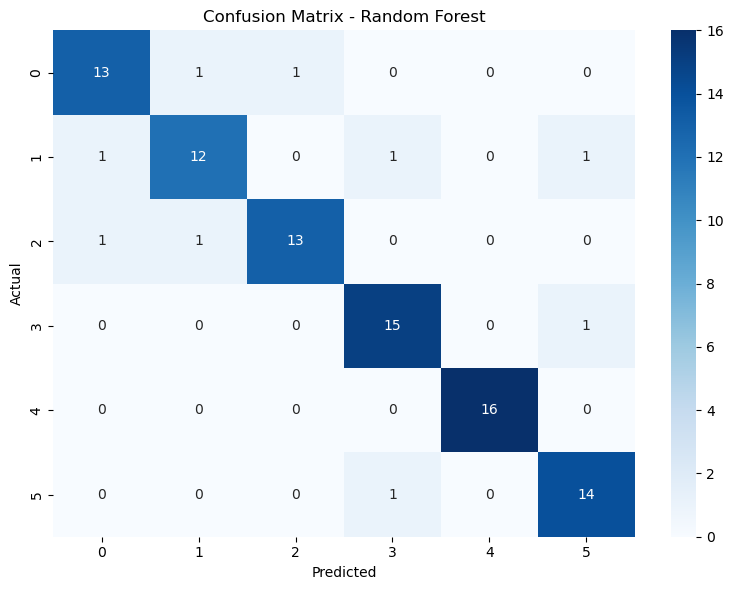

In [12]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png')
plt.show()

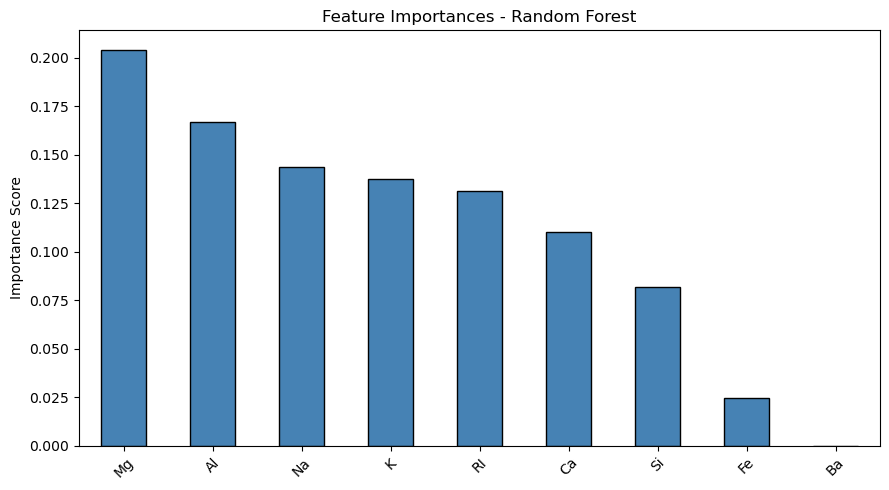

In [13]:
#Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Bagging and Boosting Methods

In [14]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

print("Bagging Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_bag), 4))
print("Precision:", round(precision_score(y_test, y_pred_bag, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_bag, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_bag, average='weighted'), 4))

Bagging Performance:
Accuracy : 0.8804
Precision: 0.8808
Recall   : 0.8804
F1-Score : 0.8791


In [15]:
#AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_ada), 4))
print("Precision:", round(precision_score(y_test, y_pred_ada, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_ada, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_ada, average='weighted'), 4))

AdaBoost Performance:
Accuracy : 0.4891
Precision: 0.458
Recall   : 0.4891
F1-Score : 0.4509


In [16]:
#Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_gb), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_gb, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_gb, average='weighted'), 4))

Gradient Boosting Performance:
Accuracy : 0.913
Precision: 0.9142
Recall   : 0.913
F1-Score : 0.913


            Model  Accuracy  F1-Score
    Random Forest    0.9022    0.9017
          Bagging    0.8804    0.8791
         AdaBoost    0.4891    0.4509
Gradient Boosting    0.9130    0.9130


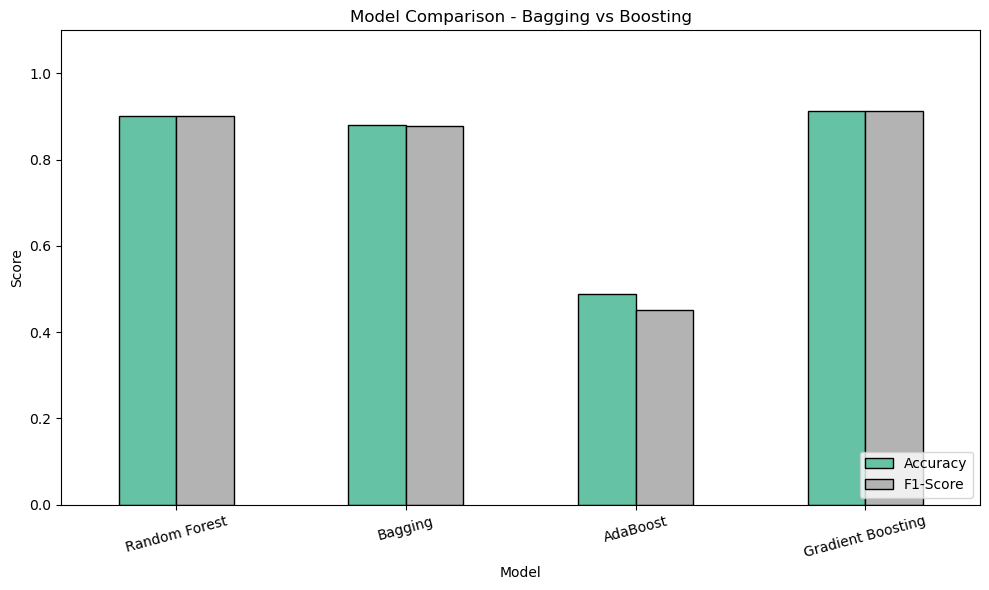

In [17]:
#Model Comparison Chart
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_bag), 4),
        round(accuracy_score(y_test, y_pred_ada), 4),
        round(accuracy_score(y_test, y_pred_gb), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_rf, average='weighted'), 4),
        round(f1_score(y_test, y_pred_bag, average='weighted'), 4),
        round(f1_score(y_test, y_pred_ada, average='weighted'), 4),
        round(f1_score(y_test, y_pred_gb, average='weighted'), 4)
    ]
})
print(comparison.to_string(index=False))

comparison.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Model Comparison - Bagging vs Boosting')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

## Additional Notes

### 1. Bagging and Boosting Methods — Explanation & Differences

#### Bagging (Bootstrap Aggregating)

Bagging is an ensemble technique where multiple models are trained **in parallel** on different random subsets of the training data (selected with replacement — called bootstrap sampling).

- Each model is trained **independently** of the others.
- For classification, the final prediction is made by **majority voting** across all models.
- For regression, the final prediction is the **average** of all model outputs.
- Bagging primarily reduces **variance**, which helps prevent overfitting.
- **Example:** Random Forest is a classic bagging-based algorithm — it builds multiple decision trees on random subsets of data and features.

#### Boosting

Boosting is an ensemble technique where models are trained **sequentially** — each new model focuses on correcting the mistakes made by the previous model.

- Misclassified samples are assigned **higher weights** so the next model pays more attention to them.
- The final prediction is a **weighted combination** of all models.
- Boosting primarily reduces **bias**, leading to a more accurate model.
- **Examples:** AdaBoost, Gradient Boosting, XGBoost, LightGBM.

#### Key Differences Between Bagging and Boosting

| Aspect | Bagging | Boosting |
|---|---|---|
| Training Style | Parallel (independent models) | Sequential (dependent models) |
| Main Goal | Reduces Variance | Reduces Bias |
| Overfitting Risk | Low | Higher (if not tuned properly) |
| Data Sampling | Random with replacement | Weighted sampling |
| Speed | Faster | Slower |
| Example Algorithms | Random Forest, Bagging Classifier | AdaBoost, Gradient Boosting, XGBoost |

---

### 2. Handling Imbalanced Data

Imbalanced data occurs when one class has significantly more samples than other classes. In such cases, the model becomes biased toward the majority class and performs poorly on minority classes.

#### Strategies to Handle Imbalanced Data

**1. SMOTE (Synthetic Minority Oversampling Technique)**
- Generates **synthetic (artificial) samples** for minority classes.
- It creates new samples by interpolating between existing minority class samples.
- This is the technique applied in Task 3 of this assignment.

**2. Random Oversampling**
- Randomly duplicates existing minority class samples.
- Simple but can lead to overfitting on repeated samples.

**3. Random Undersampling**
- Reduces the number of majority class samples to balance the dataset.
- Risk of losing important information from the majority class.

**4. Class Weight Parameter**
- Most sklearn models support `class_weight='balanced'`.
- This automatically penalizes misclassification of minority classes more heavily during training.
- No change in data is needed — just a parameter setting.

**5. Use Appropriate Evaluation Metrics**
- Plain **Accuracy** is misleading for imbalanced data (a model predicting only the majority class can still show 90%+ accuracy).
- Always use **Precision, Recall, F1-Score, and ROC-AUC** for imbalanced datasets, as they reveal how well the model handles minority classes.